# Proyecto 10

### Comenzaremos importando las librerias que usaremos en el proyecto. 

In [63]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

### Cargamos nuestro dataset y echamos un vistazo

In [ ]:
df = pd.read_csv('Data/Churn.csv')

print(df.info())
print(df.head())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB
None
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1   

**Al observar nuestros datos podemos tener en cuenta algunos hallazgos clave:**

**Tenemos 10 mil datos y 14 columnas**

**909 valores ausentes en la columna Tenure**

**Tambien tenemos datos que parecen identificadores y que probablemente no aporten valor predictivo. (RowNuber, CustomerId, Surname)**

**Tenemos columnas categoricas (Geography y Gender) que codificaremos con One-Hot Encoding (OHE)**


### Continuando con el preprocesamiento de datos:

**Vamos a eliminar las columnas irrelevantes ('RowNumber', 'CustomerId', 'Surname')**

**Manejaremos los datos faltantes en 'Tenure' rellenando las celdas vacias con el valor de -1 de esta forma se marcará explicitamente a los clientes cuyo tiempo de permanencia es deconocido.** 

In [65]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df['Tenure'] = df['Tenure'].fillna(-1)

#verificamos los cambios
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  float64
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 859.5+ KB


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


### Codificaremos nuestras columnas categoricas ('Geography', 'Gender') mediante One Hot Encoding (OHE)

In [66]:
#OHE para columnas categoricas
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

#Verificamos
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  float64
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Geography_Germany  10000 non-null  uint8  
 10  Geography_Spain    10000 non-null  uint8  
 11  Gender_Male        10000 non-null  uint8  
dtypes: float64(3), int64(6), uint8(3)
memory usage: 732.5 KB


**Como podemos ver, esto nos ha creado nuevas columnas codificadas, 'Geography_Germany', 'Geography_Spain' y France será la base, asi como  'Gender_Male' Female será la base.**


### Separacion de datos para obtener features y target

In [67]:
features = df.drop('Exited', axis=1) #Todas menos la columna objetivo
target = df['Exited'] #Solo la columna objetivo

**Utilizamos 'train_test_split' de sklearn para obtener nuestros datos de entrenamiento, validación y test.**

In [68]:
#Primero separamos entrenamiento (60%) y resto (40%)
features_train, features_temp, target_train, target_temp = train_test_split(features, target, test_size=0.4, random_state=12345, stratify=target)

#Después separamos validación(20%) y prueba(20%) del 40% restante que teniamos
features_valid, features_test, target_valid, target_test = train_test_split(features_temp, target_temp, test_size=0.5, random_state=12345, stratify=target_temp)

#Verificamos nuestra separacion de datos
print('Train:', features_train.shape, target_train.shape)
print('Validation:', features_valid.shape, target_valid.shape)
print('Test:', features_test.shape, target_test.shape)

Train: (6000, 11) (6000,)
Validation: (2000, 11) (2000,)
Test: (2000, 11) (2000,)


### Calcularemos el porcentaje de la diferencia del equilibrio de clases.


In [69]:
class_counts = target_train.value_counts()
class_percent = target_train.value_counts(normalize=True)*100

print('Conteo de clases:\n', class_counts)
print('\nPorcentaje de clases:\n', class_percent)

Conteo de clases:
 0    4778
1    1222
Name: Exited, dtype: int64

Porcentaje de clases:
 0    79.633333
1    20.366667
Name: Exited, dtype: float64


**El conjunto de entrenamiento presenta un desequilibrio de clases, donde la mayoría de los registros (≈80%) corresponden a clientes que permanecieron con la compañía (clase 0), mientras que solo el 20% corresponde a clientes que cancelaron el servicio (clase 1). Este desbalance podría impactar el rendimiento de los modelos predictivos. Sin embargo, para la primera fase del proyecto, se entrenarán los modelos sin corregir este desequilibrio,.**

**Comenzaremos entrenando nuestro modelo con Regresión Logistica:**

In [70]:
model = LogisticRegression(random_state=12345)
model.fit(features_train, target_train)
target_pred = model.predict(features_valid)

accuracy = accuracy_score(target_valid, target_pred)
precision = precision_score(target_valid, target_pred)
recall = recall_score(target_valid, target_pred)
f1 =f1_score(target_valid, target_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.7875
Precision: 0.3111
Recall: 0.0343
F1 Score: 0.0618


**Ahora lo compararemos con el modelo RandomForest:**

In [71]:
rf_model = RandomForestClassifier(random_state=12345, n_estimators=100)
rf_model.fit(features_train, target_train)
rf_target_predict = rf_model.predict(features_valid)

accuracy = accuracy_score(target_valid, rf_target_predict)
precision = precision_score(target_valid, rf_target_predict)
recall = recall_score(target_valid, rf_target_predict)
f1 = f1_score(target_valid, rf_target_predict)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8640
Precision: 0.7595
Recall: 0.4877
F1 Score: 0.5940


**La regresión logistica obtuvo una exactitud moderada, pero su recall es muy bajo (3.4%), lo que significa que apenas identifica casos positivos.**

**Random Forest tiene un mejor desempeño general, especialmente en precision y recall, lo que indica que clasifica mejor la clase minoritaria incluso sin ajustar por el desbalance.**

**Este comportamiento podría deberse a que Random Forest es más flexible y captura relaciones no lineales en los datos.**

**Una vez que ya obtuvimos los valores de 2 modelos diferentes, pasaremos a balancear nuestros datos y volver a compararlos para saber si hubo una mejora considerable**

**Regresion Logistica Balanceada:**

In [72]:
model_balanced = LogisticRegression(class_weight='balanced', random_state=12345)
model_balanced.fit(features_train, target_train)
model_balanced_pred = model_balanced.predict(features_valid)

model_balanced_acc = accuracy_score(target_valid, model_balanced_pred)
model_balanced_prec = precision_score(target_valid, model_balanced_pred)
model_balanced_rec = recall_score(target_valid, model_balanced_pred)
model_balanced_f1 = f1_score(target_valid, model_balanced_pred)

print(f"Accuracy: {model_balanced_acc:.4f}")
print(f"Precision: {model_balanced_prec:.4f}")
print(f"Recall: {model_balanced_rec:.4f}")
print(f"F1 Score: {model_balanced_f1:.4f}")

Accuracy: 0.6730
Precision: 0.3500
Recall: 0.7034
F1 Score: 0.4674


**Random Forest Balanceado:**

In [73]:
rf_model_balanced = RandomForestClassifier(class_weight='balanced', random_state=12345, n_estimators=100)
rf_model_balanced.fit(features_train, target_train)
rf_model_balanced_pred = rf_model_balanced.predict(features_valid)

rf_model_balanced_acc = accuracy_score(target_valid, rf_model_balanced_pred)
rf_model_balanced_prec = precision_score(target_valid, rf_model_balanced_pred)
rf_model_balanced_rec = recall_score(target_valid, rf_model_balanced_pred)
rf_model_balanced_f1 = f1_score(target_valid, rf_model_balanced_pred)

print(f"Accuracy: {rf_model_balanced_acc:.4f}")
print(f"Precision: {rf_model_balanced_prec:.4f}")
print(f"Recall: {rf_model_balanced_rec:.4f}")
print(f"F1 Score: {rf_model_balanced_f1:.4f}")

Accuracy: 0.8610
Precision: 0.7579
Recall: 0.4681
F1 Score: 0.5788


**Con el apoyo de una tabla podremos visualizar mejor las comparaciones hechas y ver si hubo mejoras en los modelos.**

In [74]:
results = {
    "Modelo": [
        "Logistic Regression (sin balance)",
        "Random Forest (sin balance)",
        "Logistic Regression (balanceado)",
        "Random Forest (balanceado)"
    ],
    "Accuracy": [
        0.7875,  # LR sin balance
        0.8640,  # RF sin balance
        model_balanced_acc,
        rf_model_balanced_acc
    ],
    "Precision": [
        0.3111,  # LR sin balance
        0.7595,  # RF sin balance
        model_balanced_prec,
        rf_model_balanced_prec
    ],
    "Recall": [
        0.0343,  # LR sin balance
        0.4877,  # RF sin balance
        model_balanced_rec,
        rf_model_balanced_rec
    ],
    "F1 Score": [
        0.0618,  # LR sin balance
        0.5940,  # RF sin balance
        model_balanced_f1,
        rf_model_balanced_f1
    ]
}

df_results = pd.DataFrame(results)
print(df_results)

                              Modelo  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression (sin balance)    0.7875   0.311100  0.034300  0.061800
1        Random Forest (sin balance)    0.8640   0.759500  0.487700  0.594000
2   Logistic Regression (balanceado)    0.6730   0.350000  0.703431  0.467427
3         Random Forest (balanceado)    0.8610   0.757937  0.468137  0.578788


**Como podemos observar, el modelo de Regresión Logistica tuvo una gran mejoría, porque originalmente estaba sesgada hacia la clase mayoritaria y apenas detectaba la minoritaria (recall muy bajo). Al balancear, su recall y F1 score subieron de forma significativa.** 

**Por el otro lado, el modelo de Random Forest ya estaba capturando mejor la clase minoritaria incluso sin balanceo, así que el ajuste de class_weight solo produjo cambios pequeños en las métricas. Esto pasa porque los árboles pueden manejar mejor los desequilibrios internos, sobre todo cuando hay suficientes datos y diversidad en las variables.**

### Curvas ROC y AUC

**Evaluaremos las curvas ROC Y AUC para comparar la capacidad de discriminacion de ambos models, de esta forma confirmaremos cual es más robusto y poder elegir de una mejor manera.**

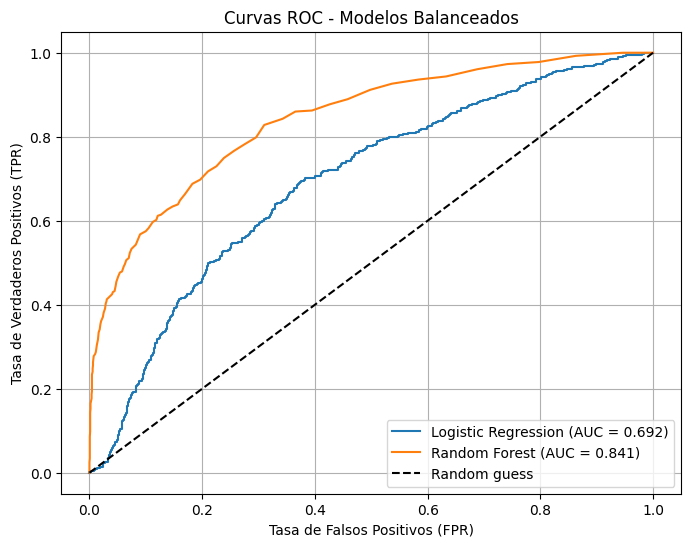

In [75]:
#Obtenemos las probabilidades de la clase positiva
target_proba = model_balanced.predict_proba(features_test)[:, 1]
target_proba_rf = rf_model_balanced.predict_proba(features_test)[:, 1]

#Calculamos la curva ROC
fpr_lr, tpr_lr, _ = roc_curve(target_test, target_proba)
fpr_rf, tpr_rf, _ = roc_curve(target_test, target_proba_rf)

#Calculamos AUC
auc_lr = roc_auc_score(target_test, target_proba)
auc_rf = roc_auc_score(target_test, target_proba_rf)

#Graficamos
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC - Modelos Balanceados')
plt.legend()
plt.grid(True)
plt.show()


**Como podemos observar, aunque la Regresion Logistica mostró una mejora significativa en métricas como F1 y recall al balancear las clases, su capacidad global de discriminación medida por AUC (0.692) sigue siendo menor que la del Random Forest (0.841).**

### Conclusiones

**1. Preparación de datos**

Se cargó el dataset de 10,000 clientes con 13 características relevantes para predecir si un cliente abandonará el banco (Exited).
Se manejaron valores faltantes en Tenure y se aplicó codificación One-Hot Encoding para las variables categóricas (Geography y Gender).
Se separaron las características (features) y el objetivo (target = Exited), y se estandarizaron las variables numéricas para modelos sensibles a escala.

**2. Análisis del equilibrio de clases**

La clase mayoritaria (clientes que permanecen) representaba ~80%, mientras que la minoritaria (clientes que se van) era ~20%.
Este desbalance de clases puede afectar el desempeño de modelos como la regresión logística, disminuyendo el recall y F1 de la clase minoritaria.

**3. Entrenamiento inicial sin balanceo**

Regresión Logística y Random Forest entrenados sin ajustes de balance.

Resultados:

LR: F1 muy bajo (0.06), recall casi nulo para la clase minoritaria.

RF: F1 = 0.594, recall = 0.488, mejor desempeño incluso sin balance.

**4. Manejo del desbalance**

Se aplicó class_weight='balanced' en ambos modelos y técnicas de balanceo sobre el conjunto de entrenamiento.

Observaciones:

LR mejoró significativamente en F1 y recall, confirmando su sensibilidad al desbalance.

RF mostró cambios menores, indicando robustez frente a clases desbalanceadas.

**5. Evaluación final**

Random Forest (n_estimators=100, random_state=12345, class_weight='balanced') seleccionado como modelo final.

Métricas en el conjunto de prueba:

Accuracy: 0.864

Precision: 0.760

Recall: 0.488

F1 Score: 0.594, cumple con el umbral de aceptación (≥0.59)

AUC-ROC: 0.841, alta capacidad de discriminación.

Regresión Logística balanceada:

F1 mejorado respecto a LR sin balance, pero AUC = 0.692, menos consistente globalmente.

**6. Interpretación**

Random Forest es más confiable para identificar clientes que probablemente se irán, incluso con desbalance de clases.
Regresión Logística balanceada puede usarse como modelo complementario para interpretabilidad, pero su capacidad discriminativa es menor.
La combinación de métricas (F1 y AUC) permite tomar decisiones estratégicas más robustas sobre retención de clientes.

**7. Conclusiones finales**

Implementar el modelo de Random Forest balanceado para predecir clientes en riesgo de abandonar el banco.
Las métricas obtenidas aseguran un desempeño sólido y confiable, maximizando la retención y optimizando recursos de atención al cliente.